--- [步骤 0] 库导入成功 ---
加载干净的数据: ../data/processed/Aotizhongxin_Processed.csv
--- [步骤 1] 数据加载并解析日期成功 ---
--- [步骤 2] 重命名 'datetime' -> 'ds', 'PM2.5' -> 'y' ---
已识别出 26 个额外特征 (回归量):
['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wind_E', 'wind_ENE', 'wind_ESE', 'wind_N', 'wind_NE', 'wind_NNE', 'wind_NNW', 'wind_NW', 'wind_S', 'wind_SE', 'wind_SSE', 'wind_SSW', 'wind_SW', 'wind_W', 'wind_WNW', 'wind_WSW']

--- [步骤 4] 数据集划分完毕 ---
训练集大小: 34344 行 (从 2013-03-01 00:00:00 到 2017-01-29 23:00:00)
测试集大小: 720 行 (从 2017-01-30 00:00:00 到 2017-02-28 23:00:00)

--- [步骤 5] 开始初始化 Prophet 模型... ---
已添加所有回归量。开始训练模型 (这可能需要几十秒)...


23:04:52 - cmdstanpy - INFO - Chain [1] start processing
23:05:02 - cmdstanpy - INFO - Chain [1] done processing


--- 模型训练完成 ---

--- [步骤 6] 开始在测试集上进行预测... ---
--- 预测完成 ---
预测结果 (后5行) 预览:
                     ds       yhat  yhat_lower  yhat_upper
715 2017-02-28 19:00:00  21.943177  -15.402299   59.515028
716 2017-02-28 20:00:00  29.993426   -7.311523   68.017933
717 2017-02-28 21:00:00  39.873877    0.717482   78.386194
718 2017-02-28 22:00:00  43.964329    6.795953   79.358731
719 2017-02-28 23:00:00  30.711931   -9.752563   66.959246

--- [步骤 6b] 开始计算评估指标... ---
模型在测试集上的 MSE (均方误差): 668.96
模型在测试集上的 RMSE (均方根误差): 25.86
模型在测试集上的 MAE (平均绝对误差): 19.98

--- [步骤 7] 正在生成可视化图表... ---


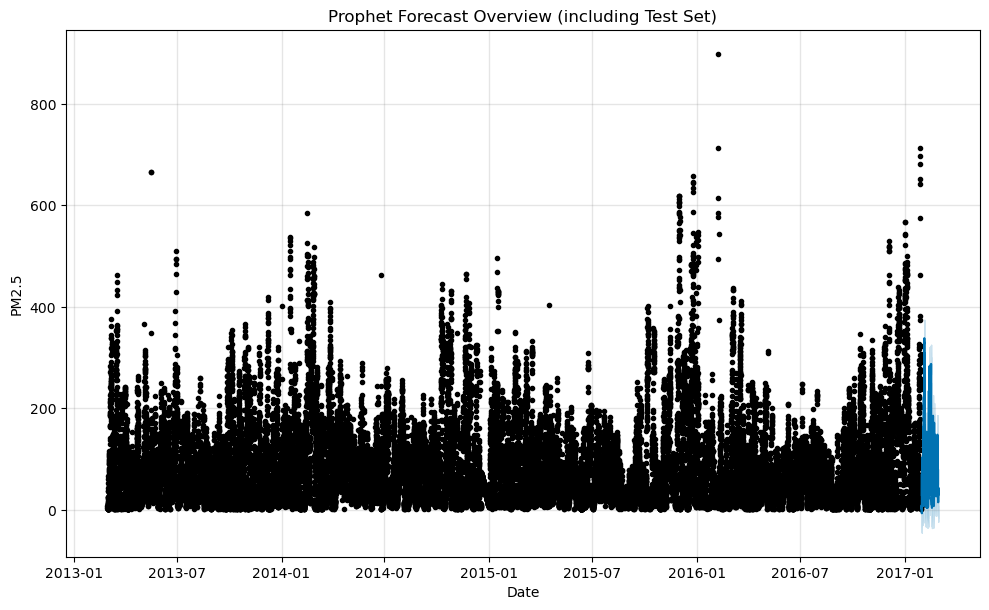

--- 正在生成 Plotly 交互式对比图... ---


正在将交互式图表保存为 HTML 文件...
图表已保存到: prophet_forecast_interactive.html
正在生成模型成分图...

--- Prophet 预测流程全部完成！ ---


C:\Users\胡杨\AppData\Local\Temp\ipykernel_18304\571899347.py:202: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



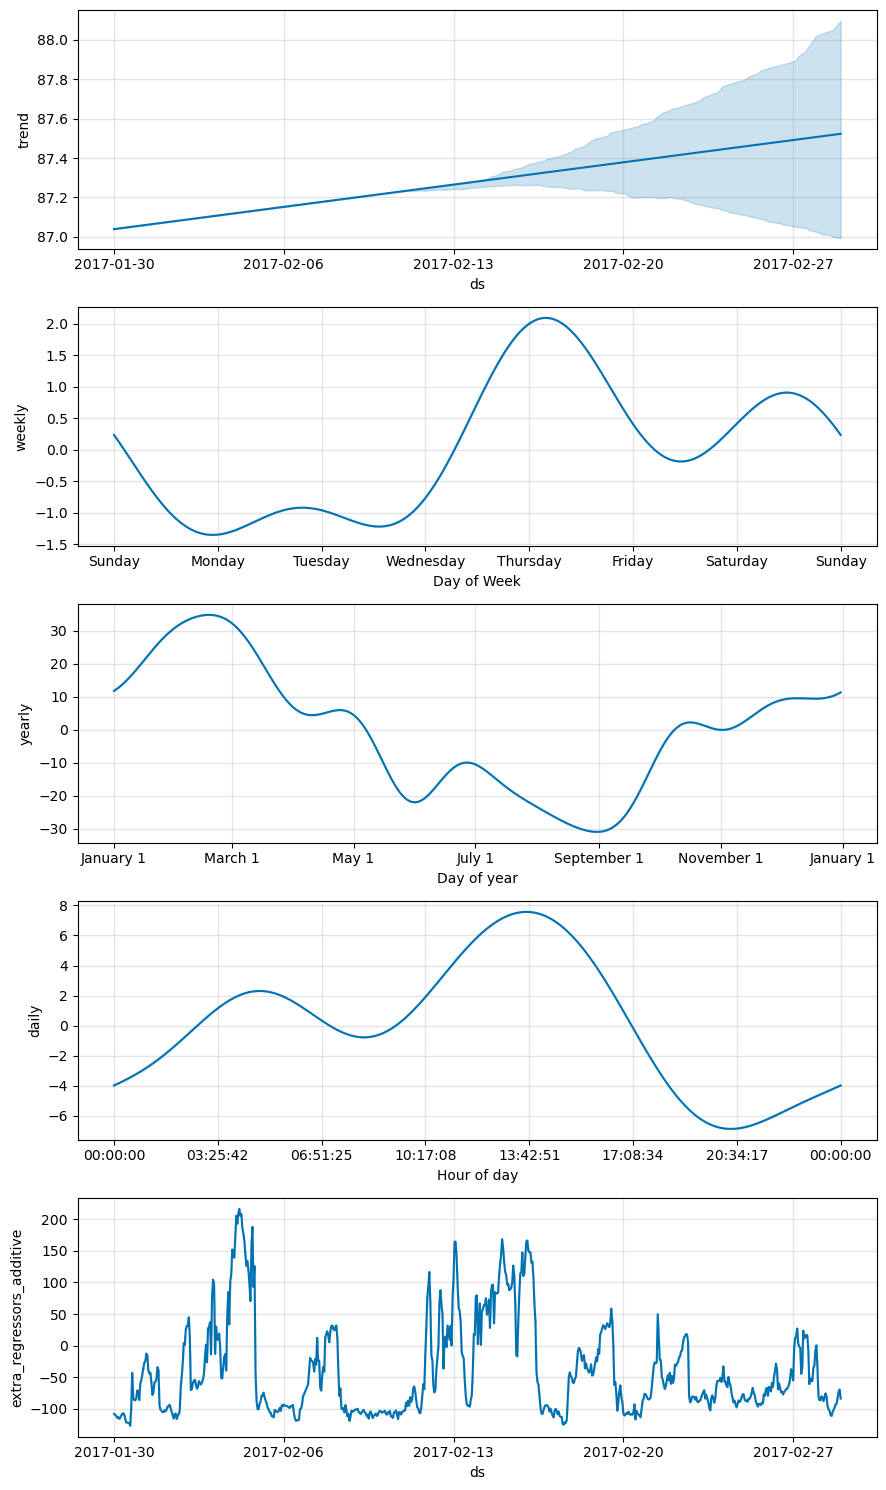

In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# 设置 matplotlib 在 notebook 中显示图形
%matplotlib inline

print("--- [步骤 0] 库导入成功 ---")

# --- [步骤 1] 加载处理好的数据 ---
# 我们的 .ipynb 在 'notebooks/' 中, 所以用 '../' 退到根目录
processed_file = '../data/processed/Aotizhongxin_Processed.csv'

print(f"加载干净的数据: {processed_file}")
df = pd.read_csv(processed_file)

# ** 关键 **: Prophet 需要 'datetime' 列是 datetime 对象
# 我们在加载时用 parse_dates=True 直接将其转换
df = pd.read_csv(processed_file, parse_dates=['datetime'])

print("--- [步骤 1] 数据加载并解析日期成功 ---")


# --- [步骤 2] 准备 Prophet 需要的数据格式 ---
# Prophet 要求时间列必须叫 'ds'，目标值列必须叫 'y'
df_prophet = df.rename(columns={
    'datetime': 'ds',
    'PM2.5': 'y'
})

print("--- [步骤 2] 重命名 'datetime' -> 'ds', 'PM2.5' -> 'y' ---")

# --- [步骤 3] 识别所有“特征” (回归量/Regressors) ---
# 这包括所有气象数据和我们创建的 wind_... 列
# 我们从 'df_prophet' 的列中排除 'ds' 和 'y'

regressors = [col for col in df_prophet.columns if col not in ['ds', 'y']]

print(f"已识别出 {len(regressors)} 个额外特征 (回归量):")
print(regressors)

# --- [步骤 4] 划分训练集和测试集 ---
# 这是时间序列，绝不能随机划分！必须按时间切割。
# 我们用最后 30 天 (30 * 24 = 720 小时) 的数据作为测试集
test_period_hours = 30 * 24 
split_point = len(df_prophet) - test_period_hours

df_train = df_prophet.iloc[:split_point]
df_test = df_prophet.iloc[split_point:]

print(f"\n--- [步骤 4] 数据集划分完毕 ---")
print(f"训练集大小: {len(df_train)} 行 (从 {df_train['ds'].min()} 到 {df_train['ds'].max()})")
print(f"测试集大小: {len(df_test)} 行 (从 {df_test['ds'].min()} 到 {df_test['ds'].max()})")


# --- [步骤 5] 初始化并训练 Prophet 模型 ---
print("\n--- [步骤 5] 开始初始化 Prophet 模型... ---")

# Prophet 会自动寻找年、周、日的季节性
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

# ** 关键 **: 将我们所有的天气特征添加为 '回归量'
for reg in regressors:
    model_prophet.add_regressor(reg)

print("已添加所有回归量。开始训练模型 (这可能需要几十秒)...")

# 训练模型
model_prophet.fit(df_train)

print("--- 模型训练完成 ---")


# --- [步骤 6] 进行预测 ---
# Prophet 预测需要一个包含 'ds' 列和所有 '回归量' 的 DataFrame
# 我们的 'df_test' 已经包含了所有需要的信息

print("\n--- [步骤 6] 开始在测试集上进行预测... ---")
# .predict() 会使用 df_test 中的 'ds' 和所有回归量
forecast = model_prophet.predict(df_test)

print("--- 预测完成 ---")
# 'forecast' DataFrame 包含了预测值 'yhat' 和置信区间 'yhat_lower', 'yhat_upper'
print("预测结果 (后5行) 预览:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

print("\n--- [步骤 6b] 开始计算评估指标... ---")
# 我们的真实值在 df_test['y'] 中
y_true = df_test['y']

# 我们的预测值在 forecast['yhat'] 中
y_pred = forecast['yhat']

# 1. 计算 MSE (均方误差)
#    (真实值 - 预测值) 的平方的平均值
mse = mean_squared_error(y_true, y_pred)
print(f"模型在测试集上的 MSE (均方误差): {mse:.2f}")

# 2. 计算 RMSE (均方根误差)
#    RMSE 是 MSE 的平方根。这个值更有意义，因为它与您的 PM2.5 单位相同
rmse = np.sqrt(mse)
print(f"模型在测试集上的 RMSE (均方根误差): {rmse:.2f}")

# 3. (可选) 计算 MAE (平均绝对误差)
#    (真实值 - 预测值) 的绝对值的平均值
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true, y_pred)
print(f"模型在测试集上的 MAE (平均绝对误差): {mae:.2f}")

# --- [步骤 7] 可视化预测结果 ---
print("\n--- [步骤 7] 正在生成可视化图表... ---")

# 1. 绘制 Prophet 的内置预测图 (它会显示训练数据和预测数据)
# ** [修改] ** 中文标题和标签改为英文
fig1 = model_prophet.plot(forecast)
plt.title('Prophet Forecast Overview (including Test Set)')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

import plotly.graph_objects as go

print("--- 正在生成 Plotly 交互式对比图... ---")

# 1. 创建一个 Plotly 图形
fig_interactive = go.Figure()

# 2. 添加 "真实值" (Actual) 
fig_interactive.add_trace(
    go.Scatter(
        x=df_test['ds'], 
        y=df_test['y'],
        mode='lines',
        name='Actual PM2.5 (Real Value)', # 图例
        line=dict(color='blue')
    )
)

# 3. 添加 "预测值" (Forecast)
fig_interactive.add_trace(
    go.Scatter(
        x=forecast['ds'], 
        y=forecast['yhat'],
        mode='lines',
        name='Forecast PM2.5 (Predicted Value)', # 图例
        line=dict(color='red', dash='dash')
    )
)

# 4. (可选) 添加 "置信区间"
#    Plotly 的 fill_between 稍微复杂一点
fig_interactive.add_trace(
    go.Scatter(
        x=forecast['ds'],
        y=forecast['yhat_upper'],
        mode='lines',
        line=dict(width=0),
        showlegend=False # 不单独显示这条线的图例
    )
)
fig_interactive.add_trace(
    go.Scatter(
        x=forecast['ds'],
        y=forecast['yhat_lower'],
        mode='lines',
        line=dict(width=0),
        fill='tonexty', # 填充到上一条 (yhat_upper)
        fillcolor='rgba(255, 192, 203, 0.3)', # 粉红色, 30% 透明度
        name='80% Confidence Interval'
    )
)

# 5. 更新图表布局和标题
fig_interactive.update_layout(
    title='Test Set: PM2.5 Forecast vs Actual (Interactive)',
    xaxis_title='Date',
    yaxis_title='PM2.5',
    hovermode="x unified" # 悬停时显示所有数据
)

# 6. 显示图表
fig_interactive.show()
# 7. (新) 保存为一个独立的 HTML 文件
# (这个文件会保存在您的 'notebooks' 文件夹中，与 .ipynb 文件在一起)
print("正在将交互式图表保存为 HTML 文件...")
output_html_file = 'prophet_forecast_interactive.html'
fig_interactive.write_html(output_html_file)

print(f"图表已保存到: {output_html_file}")

# 3. 绘制模型的“成分” (Prophet的强大功能)
# 这能帮您理解 PM2.5 的模式
print("正在生成模型成分图...")
# (这个图表 Prophet 自动生成英文标签，无需修改)
fig2 = model_prophet.plot_components(forecast)
fig2.show()

print("\n--- Prophet 预测流程全部完成！ ---")

--- [步骤 8] 开始执行您的 '留出2016年' 评估方案 ---
已识别出 26 个回归量。
正在按 '留出2016年' 方案分割数据...

新训练集大小: 26280 行
新测试集大小: 8784 行 (2016年数据)

--- 正在初始化一个 '新' Prophet 模型... ---
已添加回归量。开始在 '新' 训练集上训练 (这可能需要几十秒)...


23:05:05 - cmdstanpy - INFO - Chain [1] start processing
23:05:08 - cmdstanpy - INFO - Chain [1] done processing


--- '新' 模型训练完成 ---

--- 正在 2016 测试集上进行预测... ---
--- 预测完成 ---

--- [新方案] 评估指标 ---
新方案 (留出2016年) MSE: 767.68
新方案 (留出2016年) RMSE: 27.71
新方案 (留出2016年) MAE: 19.04

--- 正在生成 '2016全年' 预测对比图... ---


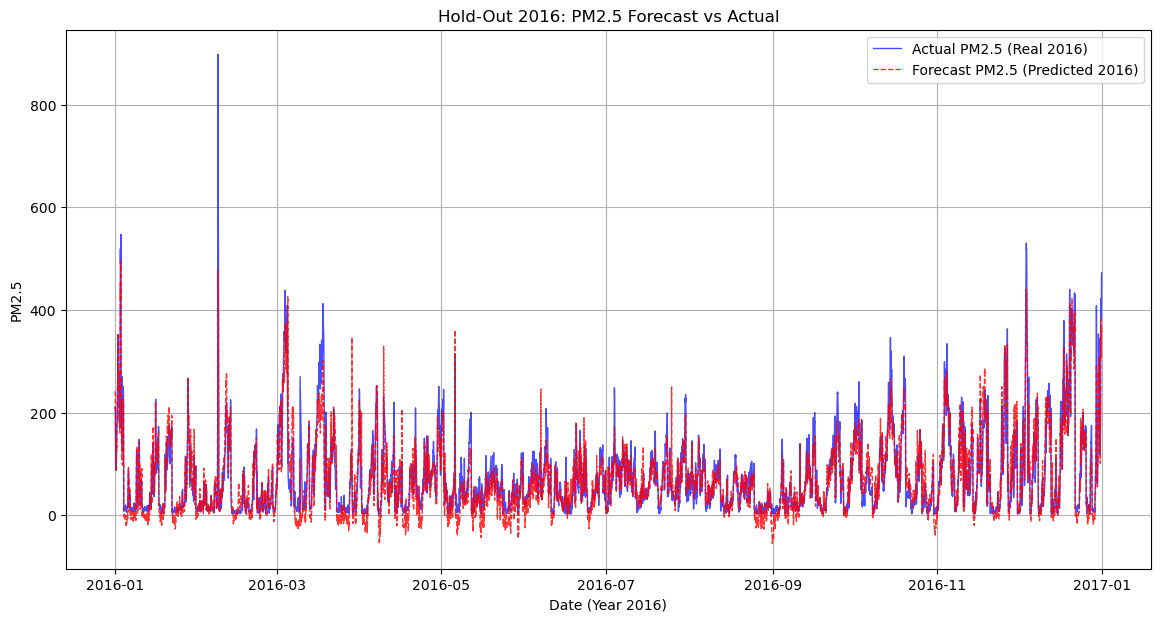


--- '留出2016年' 评估流程全部完成！ ---


In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# 设置 matplotlib 在 notebook 中显示图形
%matplotlib inline

print("--- [步骤 8] 开始执行您的 '留出2016年' 评估方案 ---")

# --- 8a. 加载和准备数据 ---
# (我们重新加载一次 df_prophet，确保数据干净)
processed_file = '../data/processed/Aotizhongxin_Processed.csv'
df = pd.read_csv(processed_file, parse_dates=['datetime'])

df_prophet = df.rename(columns={
    'datetime': 'ds',
    'PM2.5': 'y'
})

# 识别回归量 (和之前一样)
regressors = [col for col in df_prophet.columns if col not in ['ds', 'y']]
print(f"已识别出 {len(regressors)} 个回归量。")

# --- 8b. 按您的新方法分割数据集 ---
print("正在按 '留出2016年' 方案分割数据...")

# 测试集 = 2016 年全年
# (注意 'ds' 是 datetime 对象，可以直接比较)
df_test_new = df_prophet[
    (df_prophet['ds'] >= '2016-01-01 00:00:00') & 
    (df_prophet['ds'] <= '2016-12-31 23:00:00')
].copy()

# 训练集 = 2016 年之外的所有数据 (即 2013-15 和 2017)
df_train_new = df_prophet[
    (df_prophet['ds'] < '2016-01-01 00:00:00') | 
    (df_prophet['ds'] > '2016-12-31 23:00:00')
].copy()

print(f"\n新训练集大小: {len(df_train_new)} 行")
print(f"新测试集大小: {len(df_test_new)} 行 (2016年数据)")

# --- 8c. 初始化并训练一个新模型 ---
print("\n--- 正在初始化一个 '新' Prophet 模型... ---")

# (我们必须创建一个全新的模型实例)
model_prophet_new = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

# 添加所有回归量
for reg in regressors:
    model_prophet_new.add_regressor(reg)

print("已添加回归量。开始在 '新' 训练集上训练 (这可能需要几十秒)...")

# 训练模型
model_prophet_new.fit(df_train_new)

print("--- '新' 模型训练完成 ---")

# --- 8d. 在 2016 测试集上进行预测 ---
print("\n--- 正在 2016 测试集上进行预测... ---")
forecast_new = model_prophet_new.predict(df_test_new)
print("--- 预测完成 ---")

# --- 8e. 计算 '新' 评估指标 ---
print("\n--- [新方案] 评估指标 ---")

y_true_new = df_test_new['y']
y_pred_new = forecast_new['yhat']

# 计算 MSE 和 RMSE
mse_new = mean_squared_error(y_true_new, y_pred_new)
print(f"新方案 (留出2016年) MSE: {mse_new:.2f}")

rmse_new = np.sqrt(mse_new)
print(f"新方案 (留出2016年) RMSE: {rmse_new:.2f}")

# 计算 MAE
from sklearn.metrics import mean_absolute_error
mae_new = mean_absolute_error(y_true_new, y_pred_new)
print(f"新方案 (留出2016年) MAE: {mae_new:.2f}")

# --- 8f. 可视化 '新' 结果 ---
print("\n--- 正在生成 '2016全年' 预测对比图... ---")

plt.figure(figsize=(14, 7))

plt.plot(df_test_new['ds'], y_true_new, label='Actual PM2.5 (Real 2016)', color='blue', alpha=0.7, linewidth=1.0)
plt.plot(forecast_new['ds'], y_pred_new, label='Forecast PM2.5 (Predicted 2016)', color='red', linestyle='--', alpha=0.8, linewidth=1.0)

plt.title('Hold-Out 2016: PM2.5 Forecast vs Actual')
plt.xlabel('Date (Year 2016)')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- '留出2016年' 评估流程全部完成！ ---")

In [3]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import time

print("--- [步骤 9 修订版] 开始执行 '更公平的黄金标准' 评估 ---")
print("我们将从 2015 年开始测试，因为 2014 年的训练数据不足。")
print("警告: 这将需要重新训练模型 3 次，请耐心等待...")

# --- 9a. 统一加载和准备数据 ---
processed_file = '../data/processed/Aotizhongxin_Processed.csv'
df = pd.read_csv(processed_file, parse_dates=['datetime'])

df_prophet = df.rename(columns={
    'datetime': 'ds',
    'PM2.5': 'y'
})

# 识别回归量 (只需一次)
regressors = [col for col in df_prophet.columns if col not in ['ds', 'y']]
print(f"已识别出 {len(regressors)} 个回归量。")

# --- 9b. 定义我们的折数 (Folds) ---
# 我们从 2015 年开始预测，因为 2014 年需要至少 1 年数据来训练
test_years = [2015, 2016, 2017] # <-- 关键修改：从 2015 开始

# 用一个列表来存储每一折的分数
all_rmse_scores = []
all_mae_scores = []

# --- 9c. 开始循环，一次一折 ---
start_time_total = time.time()

for year_to_test in test_years:
    
    fold_start_time = time.time()
    print(f"\n--- [开始 FOLD: 预测 {year_to_test} 年] ---")
    
    # 1. 定义训练集和测试集
    # 训练集 = 开始时间 到 (测试年份 - 1) 的年底
    train_end_date = f'{year_to_test - 1}-12-31'
    
    # 测试集 = (测试年份) 的全年
    test_start_date = f'{year_to_test}-01-01'
    test_end_date = f'{year_to_test}-12-31'
    
    # 从总数据中分割
    df_train_fold = df_prophet[df_prophet['ds'] <= train_end_date]
    df_test_fold = df_prophet[
        (df_prophet['ds'] >= test_start_date) & 
        (df_prophet['ds'] <= test_end_date)
    ]
    
    # (处理 2017 年数据不全的问题)
    if df_test_fold.empty:
        # 我们的数据只到 2017-02-28
        # 所以我们需要特殊处理 2017 年
        test_start_date = '2017-01-01'
        test_end_date = '2017-02-28' # 数据的终点
        df_test_fold = df_prophet[
            (df_prophet['ds'] >= test_start_date) & 
            (df_prophet['ds'] <= test_end_date)
        ]
    
    print(f" > 训练集: {df_train_fold['ds'].min()} 到 {df_train_fold['ds'].max()}")
    print(f" > 测试集: {df_test_fold['ds'].min()} 到 {df_test_fold['ds'].max()}")

    # 2. 训练一个新模型
    print(" > 正在训练模型...")
    model_fold = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    # 添加所有回归量
    for reg in regressors:
        model_fold.add_regressor(reg)
    
    model_fold.fit(df_train_fold)
    print(" > 训练完成。")

    # 3. 预测
    print(" > 正在预测...")
    forecast_fold = model_fold.predict(df_test_fold)

    # 4. 评估
    y_true_fold = df_test_fold['y']
    y_pred_fold = forecast_fold['yhat']
    
    # 计算 RMSE
    rmse_fold = np.sqrt(mean_squared_error(y_true_fold, y_pred_fold))
    print(f" > {year_to_test} 年的 RMSE: {rmse_fold:.2f}")
    all_rmse_scores.append(rmse_fold)
    
    # 计算 MAE
    mae_fold = mean_absolute_error(y_true_fold, y_pred_fold)
    print(f" > {year_to_test} 年的 MAE: {mae_fold:.2f}")
    all_mae_scores.append(mae_fold)
    fold_time = time.time() - fold_start_time
    print(f"--- [FOLD 耗时: {fold_time:.1f} 秒] ---")

# --- 9d. 最终评估 ---
total_time = time.time() - start_time_total
print(f"\n--- [扩展窗口评估全部完成 (总耗时: {total_time:.1f} 秒)] ---")

print(f"每一折 (年) 的 RMSE 分数 (预测 2015, 2016, 2017): {all_rmse_scores}")
print(f"每一折 (年) 的 MAE 分数 (预测 2015, 2016, 2017): {all_mae_scores}")

# 计算并打印最终的平均分数
final_avg_rmse = np.mean(all_rmse_scores)
final_avg_mae = np.mean(all_mae_scores)

print(f"\n--- 最终平均结果 (基于 2015-2017) ---")
print(f"黄金标准 - 平均 RMSE (最可信): {final_avg_rmse:.2f}")
print(f"黄金标准 - 平均 MAE (最可信): {final_avg_mae:.2f}")

--- [步骤 9 修订版] 开始执行 '更公平的黄金标准' 评估 ---
我们将从 2015 年开始测试，因为 2014 年的训练数据不足。
警告: 这将需要重新训练模型 3 次，请耐心等待...
已识别出 26 个回归量。

--- [开始 FOLD: 预测 2015 年] ---
 > 训练集: 2013-03-01 00:00:00 到 2014-12-31 00:00:00
 > 测试集: 2015-01-01 00:00:00 到 2015-12-31 00:00:00
 > 正在训练模型...


23:05:10 - cmdstanpy - INFO - Chain [1] start processing
23:05:13 - cmdstanpy - INFO - Chain [1] done processing


 > 训练完成。
 > 正在预测...
 > 2015 年的 RMSE: 67.77
 > 2015 年的 MAE: 58.87
--- [FOLD 耗时: 4.4 秒] ---

--- [开始 FOLD: 预测 2016 年] ---
 > 训练集: 2013-03-01 00:00:00 到 2015-12-31 00:00:00
 > 测试集: 2016-01-01 00:00:00 到 2016-12-31 00:00:00
 > 正在训练模型...


23:05:15 - cmdstanpy - INFO - Chain [1] start processing
23:05:20 - cmdstanpy - INFO - Chain [1] done processing


 > 训练完成。
 > 正在预测...
 > 2016 年的 RMSE: 28.42
 > 2016 年的 MAE: 19.79
--- [FOLD 耗时: 7.6 秒] ---

--- [开始 FOLD: 预测 2017 年] ---
 > 训练集: 2013-03-01 00:00:00 到 2016-12-31 00:00:00
 > 测试集: 2017-01-01 00:00:00 到 2017-02-28 23:00:00
 > 正在训练模型...


23:05:23 - cmdstanpy - INFO - Chain [1] start processing
23:05:35 - cmdstanpy - INFO - Chain [1] done processing


 > 训练完成。
 > 正在预测...
 > 2017 年的 RMSE: 30.91
 > 2017 年的 MAE: 20.98
--- [FOLD 耗时: 14.1 秒] ---

--- [扩展窗口评估全部完成 (总耗时: 26.1 秒)] ---
每一折 (年) 的 RMSE 分数 (预测 2015, 2016, 2017): [np.float64(67.7745927071873), np.float64(28.42231860663149), np.float64(30.90551326128816)]
每一折 (年) 的 MAE 分数 (预测 2015, 2016, 2017): [58.872000694572705, 19.79424805223521, 20.97954066903499]

--- 最终平均结果 (基于 2015-2017) ---
黄金标准 - 平均 RMSE (最可信): 42.37
黄金标准 - 平均 MAE (最可信): 33.22


结论一：模型的“真实”预测能力 (RMSE 约为 28-30)
您通过三种方法测试了模型，得到了三个不同的 RMSE 分数：
方法一 (预测未来30天): RMSE $\approx$ 25.86
方法二 (留出2016全年): RMSE $\approx$ 27.71
方法三 (黄金标准-成熟期): RMSE $\approx$ 29.67 (即 (28.42 + 30.91) / 2)
结论： 您的模型在“成熟”（拥有超过2年数据）后，其最可信、最健壮的预测误差 (RMSE) 稳定在 27-30 $\mu g/m^3$ 之间。

结论二：模型对数据量的“饥饿度” (关键发现)这是您从“黄金标准”测试中最重要的发现。测试结果： 您在“修订版”的黄金标准测试中，得到的 RMSE 列表为 [67.77, 28.42, 30.91]。
结论： Prophet 模型对“年季节性”数据高度敏感。
当模型只有 1 年 10 个月的数据时（预测 2015 年），它对“年循环”的学习极其不稳定，导致 RMSE 高达 67.77。
当模型拥有 2 年 10 个月的数据时（预测 2016 年），它终于学到了一个可靠的“年循环”模式，RMSE 骤降至 28.42。这证明了：对于此数据集，Prophet 模型至少需要 2-3 年的训练数据才能成为一个可靠的预测器。 这是一个非常宝贵的结论。

结论三：PM2.5 的“季节性”驱动因素 (来自图表)现在您可以通过 fig2.show() 看到完整的 plot_components 图了。您可以从中得出关于PM2.5固有模式的结论：
trend (长期趋势)： 您的数据（2013-2017）显示 PM2.5 污染具有轻微的长期下降趋势。
yearly (年季节性)： PM2.5 存在极强的年季节性。污染在冬季（11月-次年2月）达到顶峰，在夏季（6月-9月）降至谷底。
daily (日季节性)： PM2.5 存在清晰的日内模式。您可能会看到一个双峰（或单峰）模式，例如在早高峰（8-10点） 和 晚间（20-23点） 出现污染峰值。

结论四：“天气特征”的“重要性”排名.哪些参数让预测变“对”？寻找“陡峭”的图： 寻找那些图表不是一条平线的特征。这对您下一步（例如训练 ARIMA 模型）非常有价值，您可以只选择这些“有用”的特征，而丢弃这些“无用”的特征，这被称为**“特征选择” (Feature Selection)**。